# econcharts Demo

This notebook demonstrates the features of the `econcharts` library for creating sharp, professional economic charts.

## Features Demonstrated

1. **Chart Generation**: Single and multi-subplot charts
2. **Scale Alignment**: Proper axis scaling for all data points
3. **Hover Tooltips**: Interactive data point display
4. **Zoom Functionality**: Drag-to-zoom and double-click reset
5. **Dark Theme**: Modern dark color scheme
6. **Customization**: Custom colors and styling

In [1]:
# Install dependencies if needed
import sys
sys.path.insert(0, '../src')

from datetime import datetime, timedelta

import econcharts
from IPython.display import Image, display, HTML

# Import FRED data utilities
sys.path.insert(0, '../src/econcharts')
from fred import (
    fetch_gdp, fetch_inflation, fetch_unemployment,
    fetch_fed_funds, fetch_sp500, fetch_treasury_10y,
    list_series
)

print("Available FRED series:")
for name, info in list_series().items():
    print(f"  {name}: {info['name']} ({info['frequency']})")

Available FRED series:
  GDP: Real GDP Growth (quarterly)
  CPI: Consumer Price Index (monthly)
  INFLATION: Inflation Rate (monthly)
  UNEMPLOYMENT: Unemployment Rate (monthly)
  FEDFUNDS: Federal Funds Rate (monthly)
  TREASURY_10Y: 10-Year Treasury Rate (daily)
  SP500: S&P 500 Index (daily)


## Real Economic Data from FRED

This notebook uses real economic data from FRED (Federal Reserve Economic Data).
The data is fetched via `pandas_datareader` and cached locally for offline use.

In [2]:
# Fetch real economic data from FRED
# Data is cached locally for offline use

# Real GDP Growth (quarterly, % change)
gdp_dates, gdp_values = fetch_gdp(start="2000-01-01")
print(f"GDP: {len(gdp_dates)} quarters from {gdp_dates[0].strftime('%Y-Q%q') if hasattr(gdp_dates[0], 'strftime') else gdp_dates[0]} to {gdp_dates[-1]}")

# Inflation Rate (monthly, % YoY)
inf_dates, inf_values = fetch_inflation(start="2000-01-01")
print(f"Inflation: {len(inf_dates)} months")

# Unemployment Rate (monthly, %)
unemp_dates, unemp_values = fetch_unemployment(start="2000-01-01")
print(f"Unemployment: {len(unemp_dates)} months")

# Federal Funds Rate (monthly, %)
fedfunds_dates, fedfunds_values = fetch_fed_funds(start="2000-01-01")
print(f"Fed Funds: {len(fedfunds_dates)} months")

# S&P 500 Index (daily)
sp500_dates, sp500_values = fetch_sp500(start="2020-01-01")
print(f"S&P 500: {len(sp500_dates)} days")

# 10-Year Treasury Rate (daily, %)
treasury_dates, treasury_values = fetch_treasury_10y(start="2020-01-01")
print(f"10Y Treasury: {len(treasury_dates)} days")

GDP: 103 quarters from 2000-Q%q to 2025-07-01 00:00:00
Inflation: 291 months
Unemployment: 311 months
Fed Funds: 312 months
S&P 500: 1521 days
10Y Treasury: 1512 days


## 1. Single Subplot Chart

A simple chart showing GDP growth rate over time.

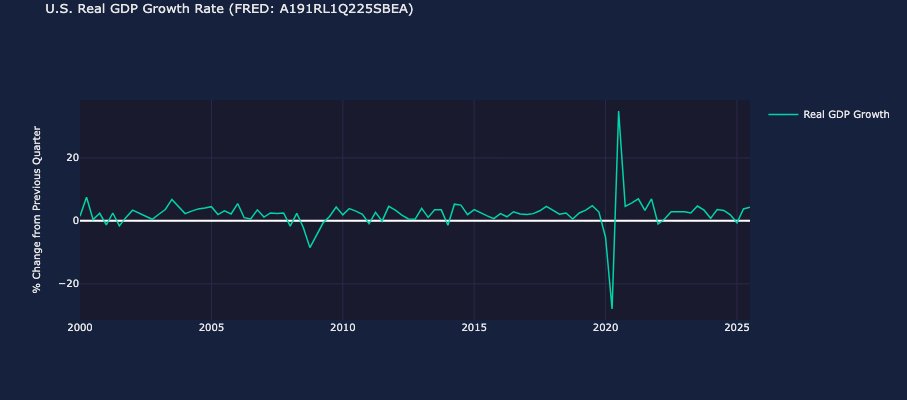

In [3]:
# Single subplot with real GDP data
chart = econcharts(num_rows=1, height=400)
chart.add_line(row=1, x=gdp_dates, y=gdp_values, name='Real GDP Growth', color='teal')
chart.set_title('U.S. Real GDP Growth Rate (FRED: A191RL1Q225SBEA)')
chart.set_yaxis(row=1, title='% Change from Previous Quarter')
chart.add_hline(row=1, y=0)
chart.enable_unified_spikeline()
chart.show()

## 2. Multi-Subplot Chart

A chart with three synchronized subplots showing GDP, Inflation, and Unemployment.

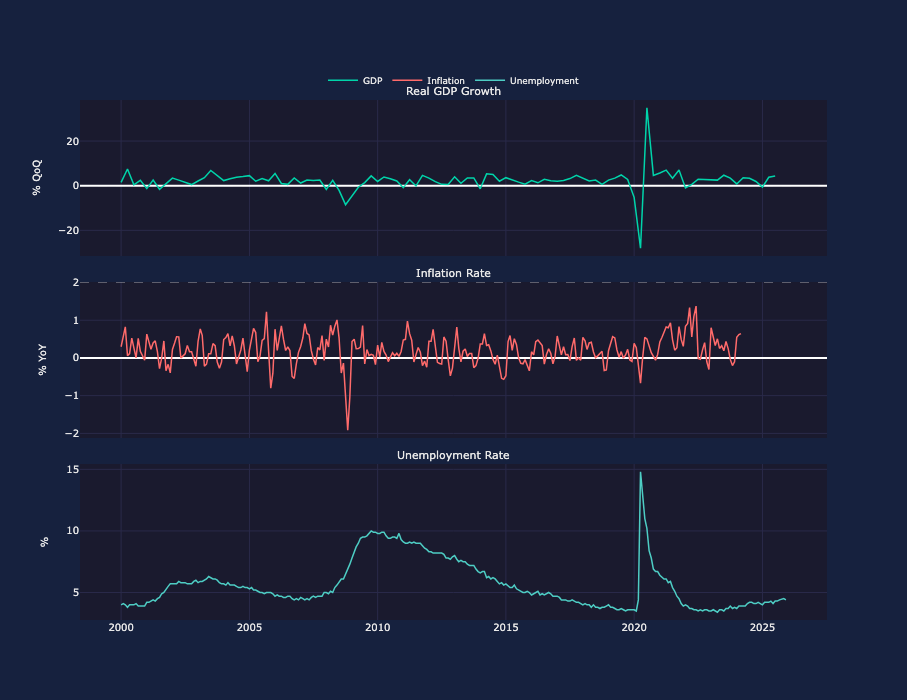

In [4]:
# Multi-subplot with real economic data
chart = econcharts(
    num_rows=3,
    subplot_titles=('Real GDP Growth', 'Inflation Rate', 'Unemployment Rate'),
    height=700,
)

chart.add_line(row=1, x=gdp_dates, y=gdp_values, name='GDP', color='teal')
chart.add_line(row=2, x=inf_dates, y=inf_values, name='Inflation', color='coral')
chart.add_line(row=3, x=unemp_dates, y=unemp_values, name='Unemployment', color='sky')

chart.set_yaxis(row=1, title='% QoQ')
chart.set_yaxis(row=2, title='% YoY')
chart.set_yaxis(row=3, title='%')

chart.add_hline(row=1, y=0)
chart.add_hline(row=2, y=2.0)  # Fed's 2% inflation target

chart.set_legend(orientation='h', position='top')
chart.enable_unified_spikeline()
chart.show()

## 3. Logarithmic Scale Chart

Stock prices often look better on a log scale to show percentage changes more accurately.

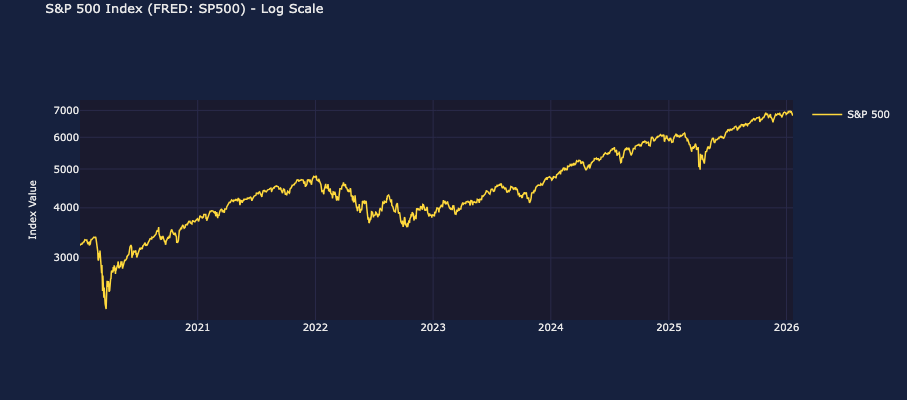

In [5]:
# S&P 500 on log scale - perfect for showing long-term growth
chart = econcharts(num_rows=1, height=400)
chart.add_line(row=1, x=sp500_dates, y=sp500_values, name='S&P 500', color='gold')
chart.set_yaxis(row=1, title='Index Value', scale_type='log')
chart.set_title('S&P 500 Index (FRED: SP500) - Log Scale')
chart.enable_unified_spikeline()
chart.show()

## 4. Multiple Series Comparison

Comparing EFFR and DGS10 on the same chart.

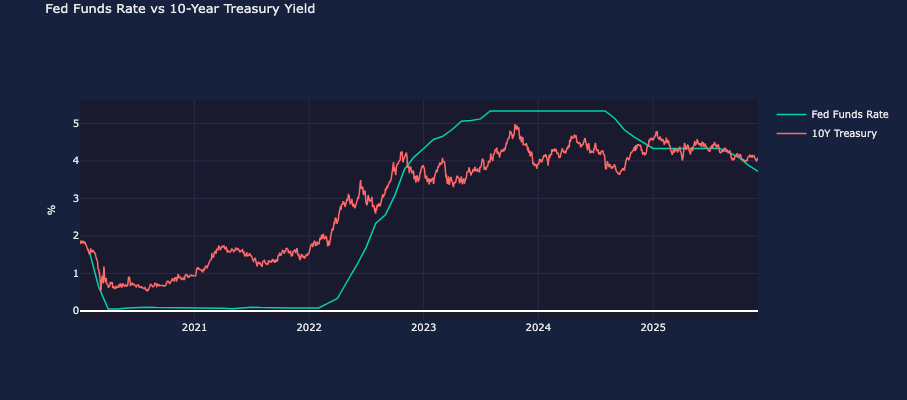

In [6]:
# Comparing Fed Funds Rate and 10-Year Treasury
# Use the same date range for comparison
common_start = max(min(fedfunds_dates), min(treasury_dates))
common_end = min(max(fedfunds_dates), max(treasury_dates))

# Filter to common range
ff_filtered = [(d, v) for d, v in zip(fedfunds_dates, fedfunds_values) 
               if common_start <= d <= common_end]
tr_filtered = [(d, v) for d, v in zip(treasury_dates, treasury_values)
               if common_start <= d <= common_end]

chart = econcharts(num_rows=1, height=400)
chart.add_line(row=1, x=[d for d, _ in ff_filtered], y=[v for _, v in ff_filtered], 
               name='Fed Funds Rate', color='teal')
chart.add_line(row=1, x=[d for d, _ in tr_filtered], y=[v for _, v in tr_filtered],
               name='10Y Treasury', color='coral')
chart.set_title('Fed Funds Rate vs 10-Year Treasury Yield')
chart.set_yaxis(row=1, title='%')
chart.add_hline(row=1, y=0)
chart.enable_unified_spikeline()
chart.show()

## 5. Custom Color Theme

You can customize the color scheme for different visual styles. Here's a light theme example.

In [ ]:
# Custom light theme with real inflation data
light_colors = {
    'background': '#ffffff',
    'paper': '#f8f9fa',
    'grid': '#dee2e6',
    'text': '#212529',
    'spike': 'rgba(0, 0, 0, 0.3)',
    'zero_line': 'rgba(0, 0, 0, 0.2)',
}

chart = econcharts(num_rows=1, height=400, colors=light_colors)
chart.add_line(row=1, x=inf_dates, y=inf_values, name='Inflation', color='#dc3545')
chart.set_title('U.S. Inflation Rate with Light Theme')
chart.set_yaxis(row=1, title='% YoY')
chart.add_hline(row=1, y=2.0)  # Fed target
chart.enable_unified_spikeline()
chart.show()

## 6. Scatter Plot with Markers

Sometimes you want to show individual data points rather than lines.

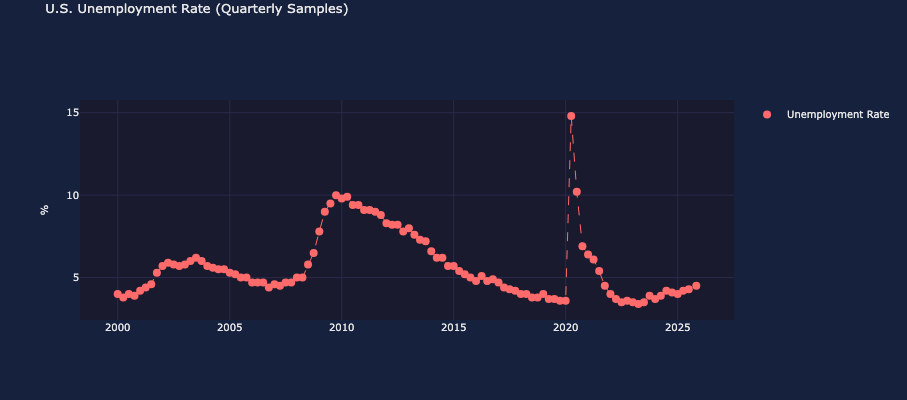

In [8]:
# Scatter plot with quarterly unemployment data points
# Sample to quarterly (every 3rd month)
quarterly_unemp_dates = unemp_dates[::3]
quarterly_unemp_values = unemp_values[::3]

chart = econcharts(num_rows=1, height=400)
chart.add_scatter(
    row=1, 
    x=quarterly_unemp_dates, 
    y=quarterly_unemp_values, 
    name='Unemployment Rate', 
    color='coral',
    marker_size=8
)
chart.add_line(
    row=1,
    x=quarterly_unemp_dates,
    y=quarterly_unemp_values,
    name='Trend',
    color='coral',
    width=1,
    dash='dash',
    showlegend=False
)
chart.set_title('U.S. Unemployment Rate (Quarterly Samples)')
chart.set_yaxis(row=1, title='%')
chart.enable_unified_spikeline()
chart.show()

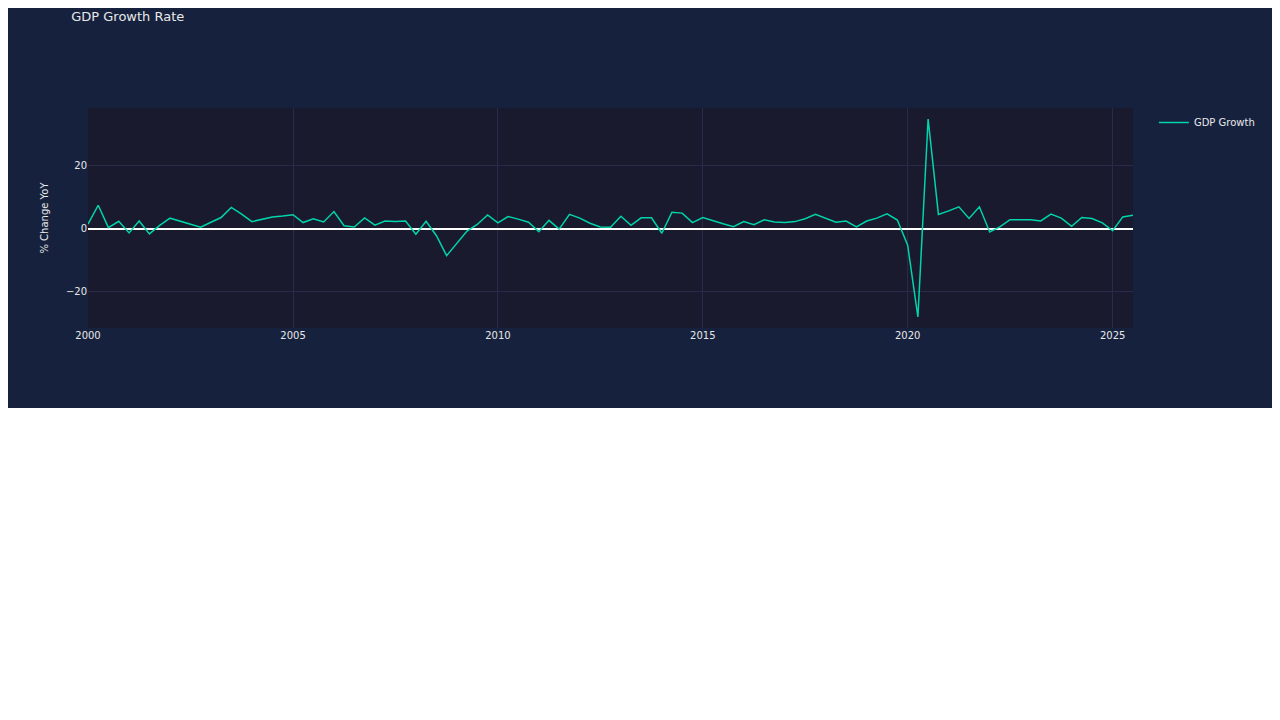

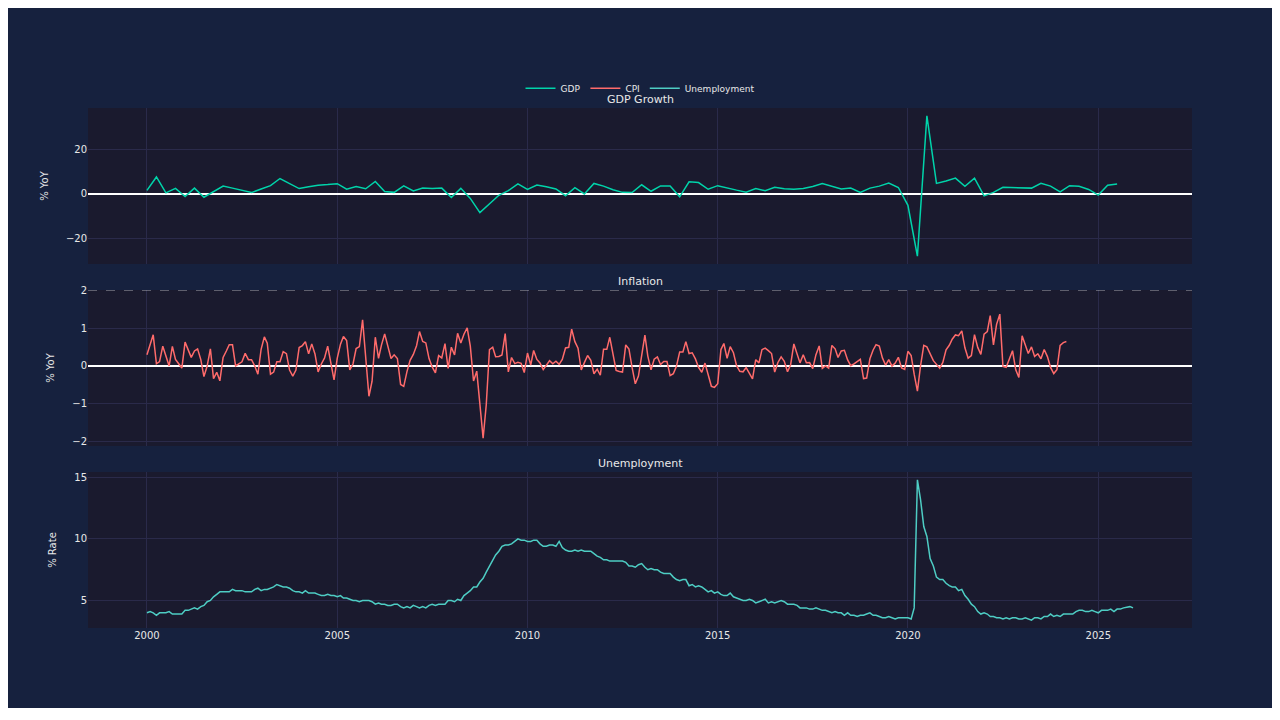

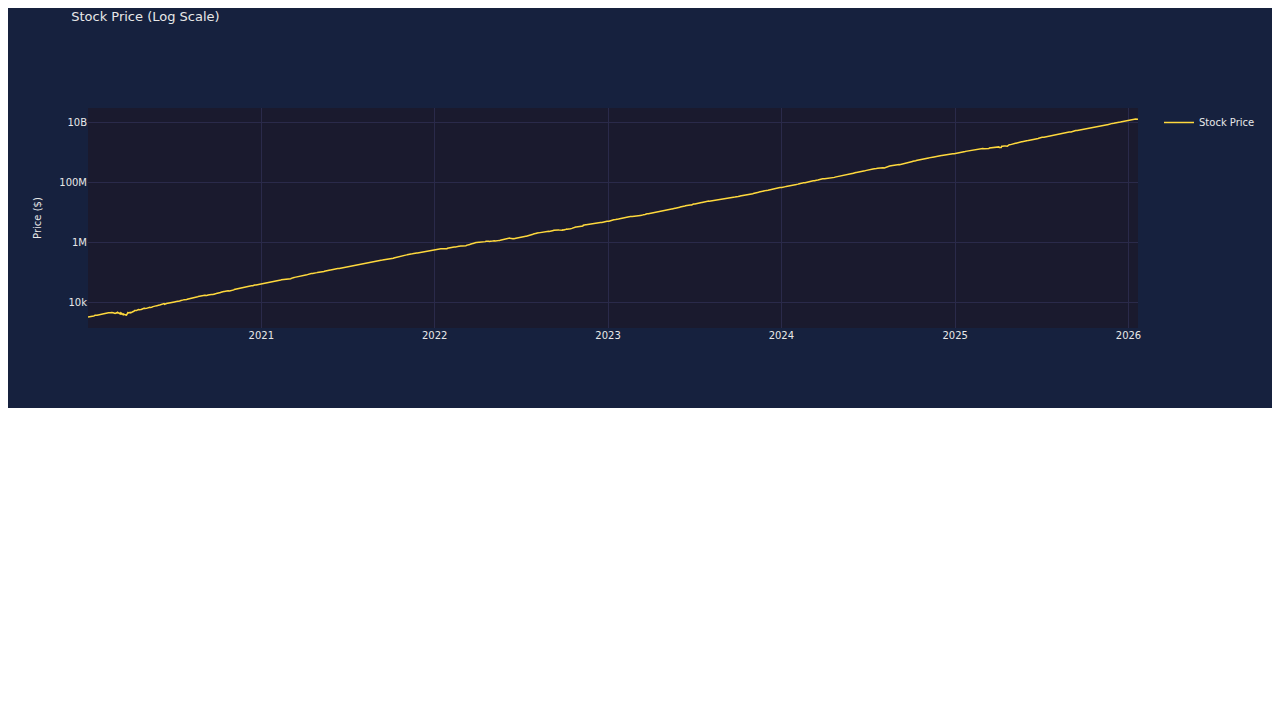

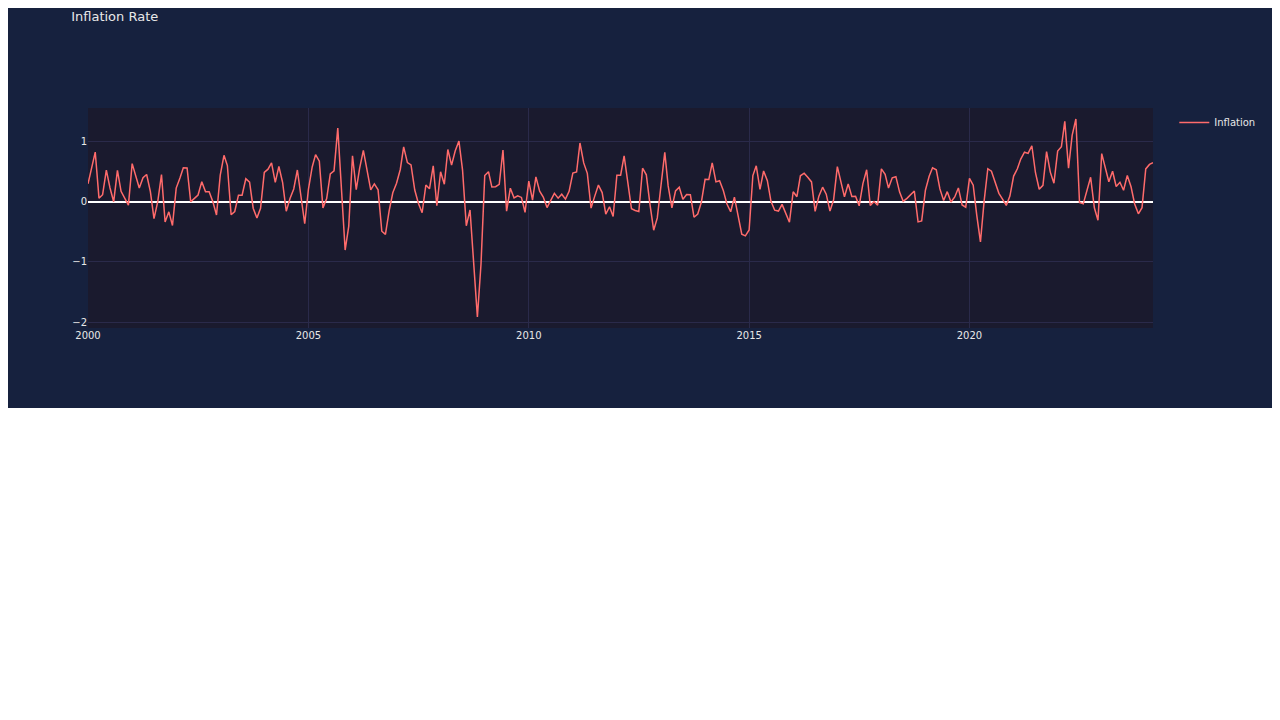

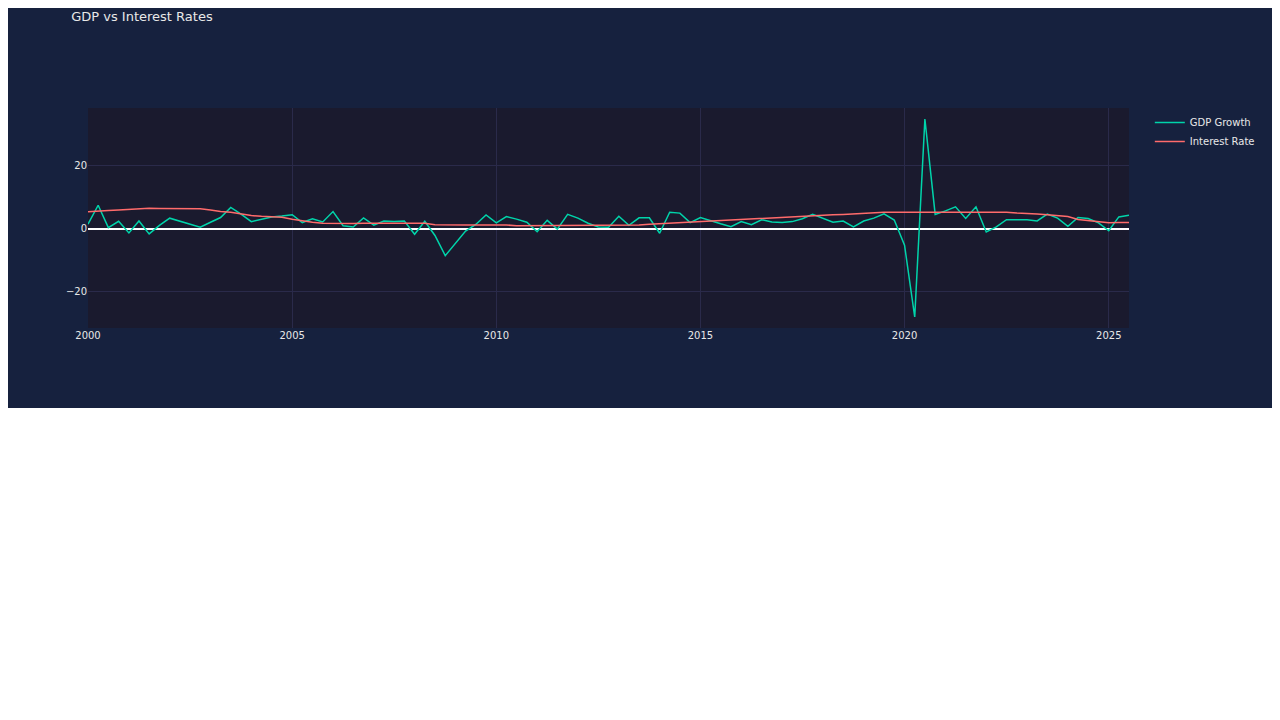

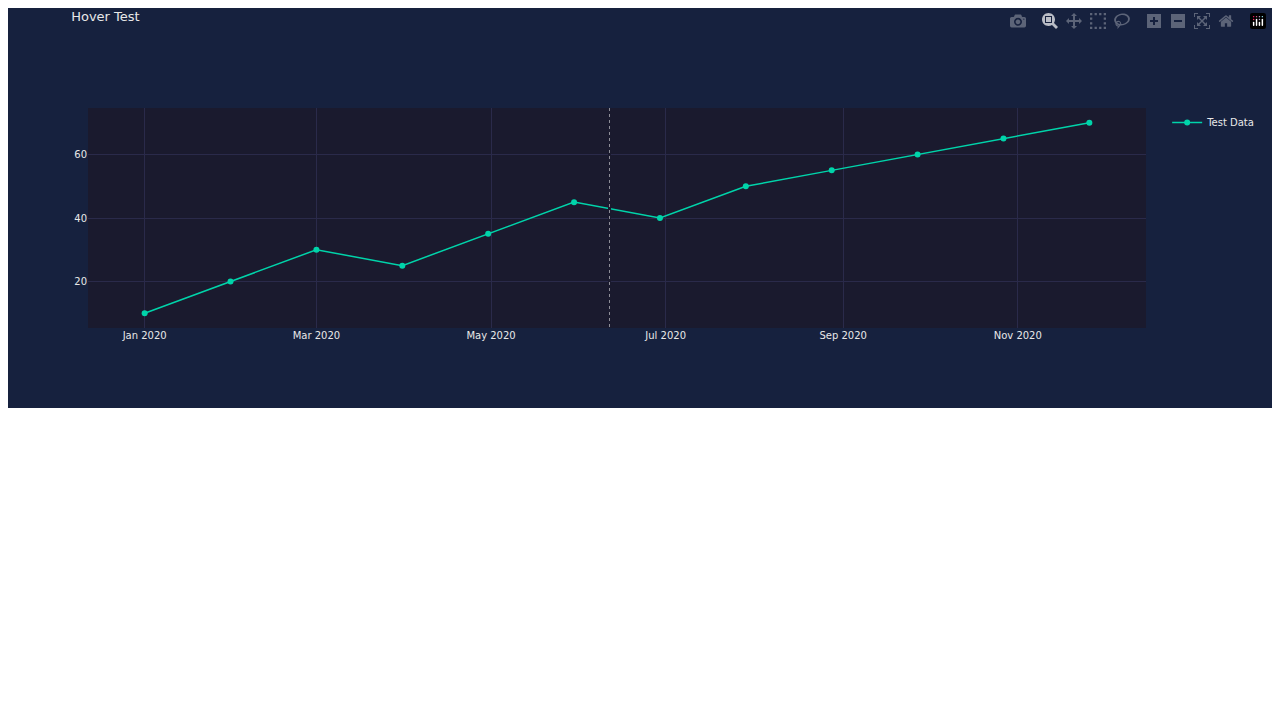

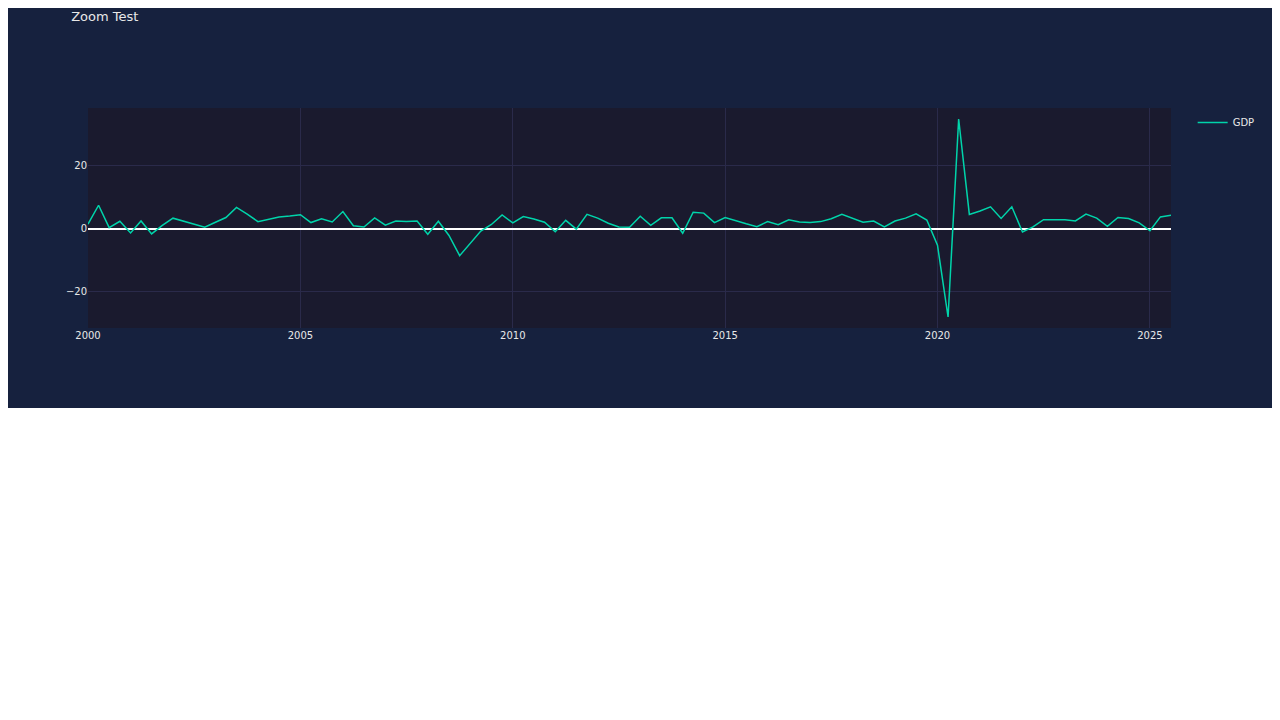

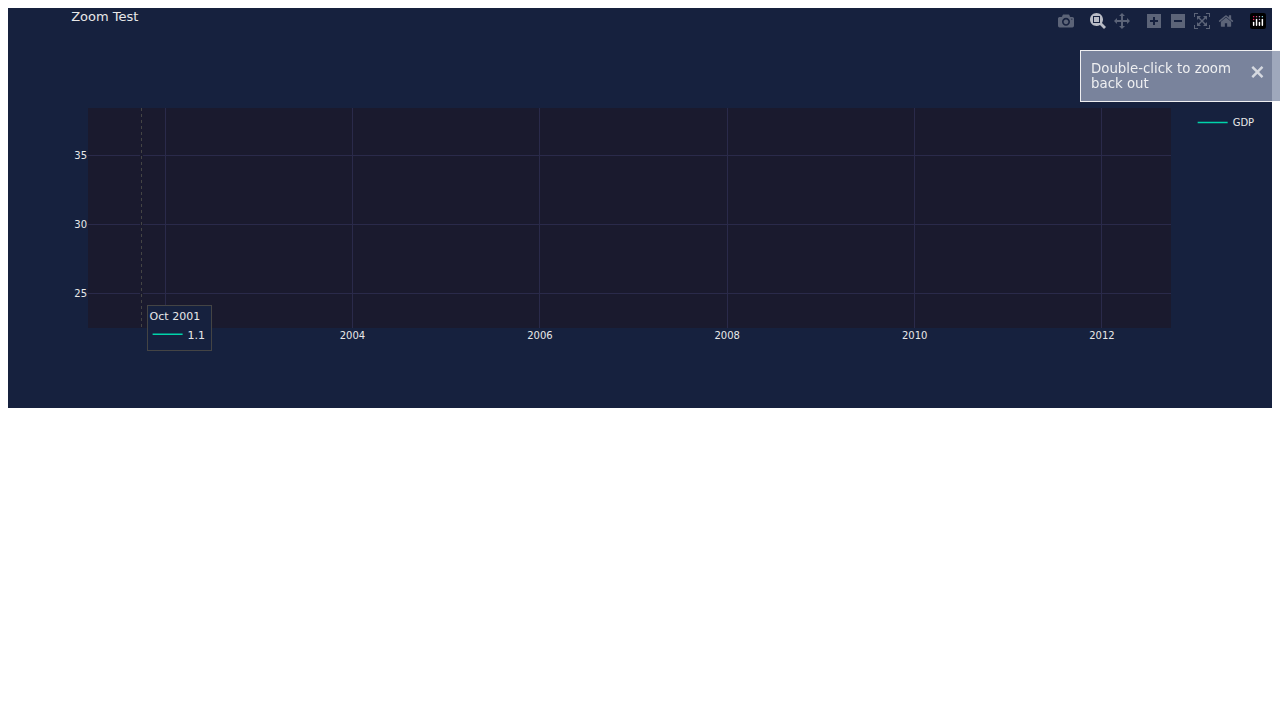

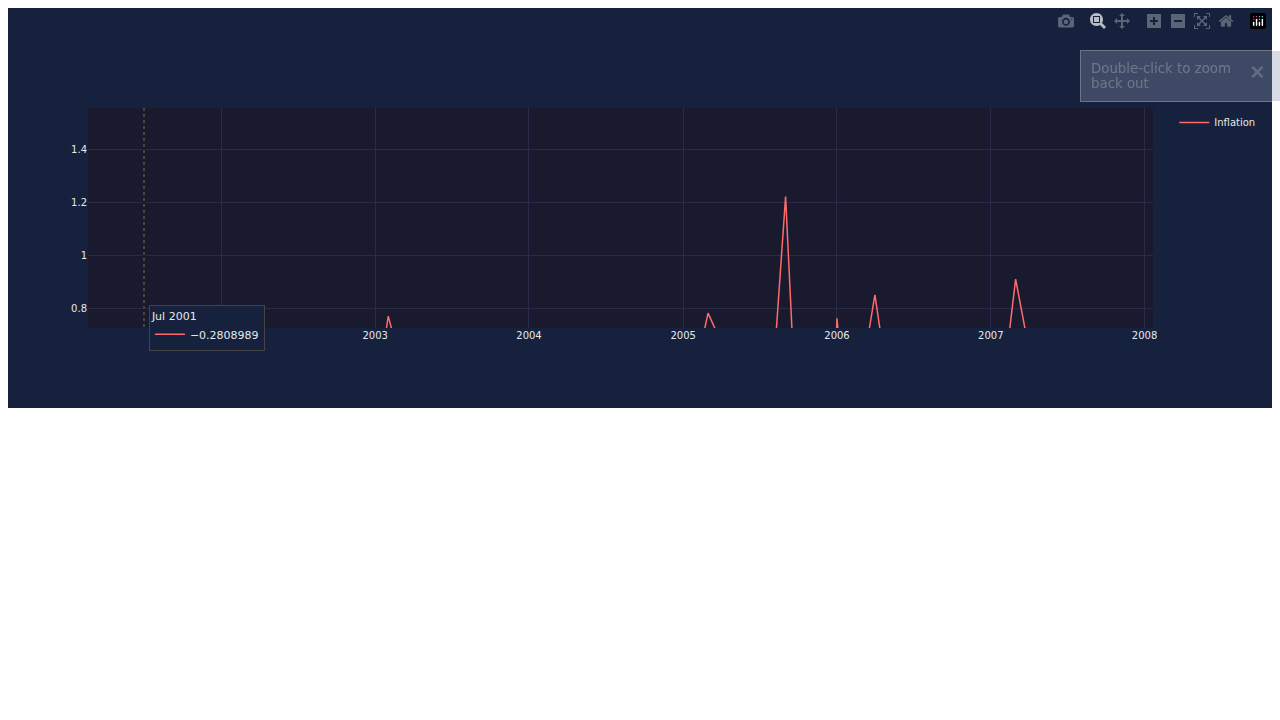

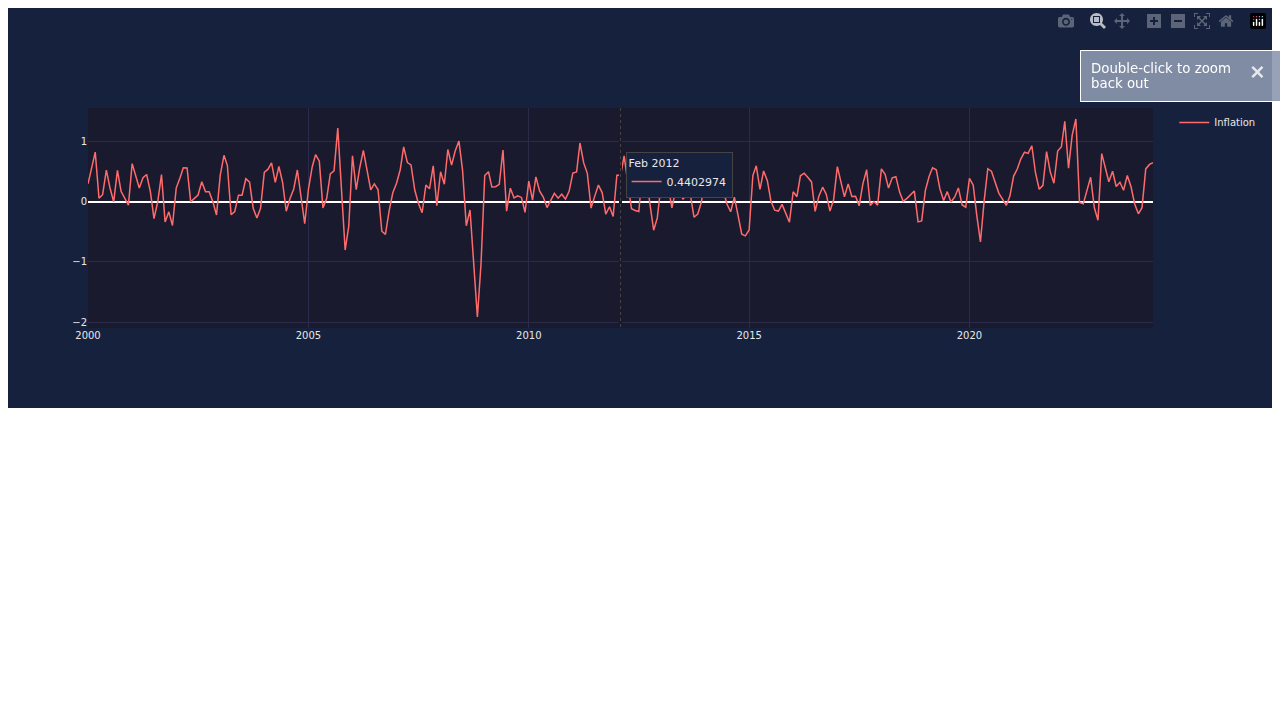

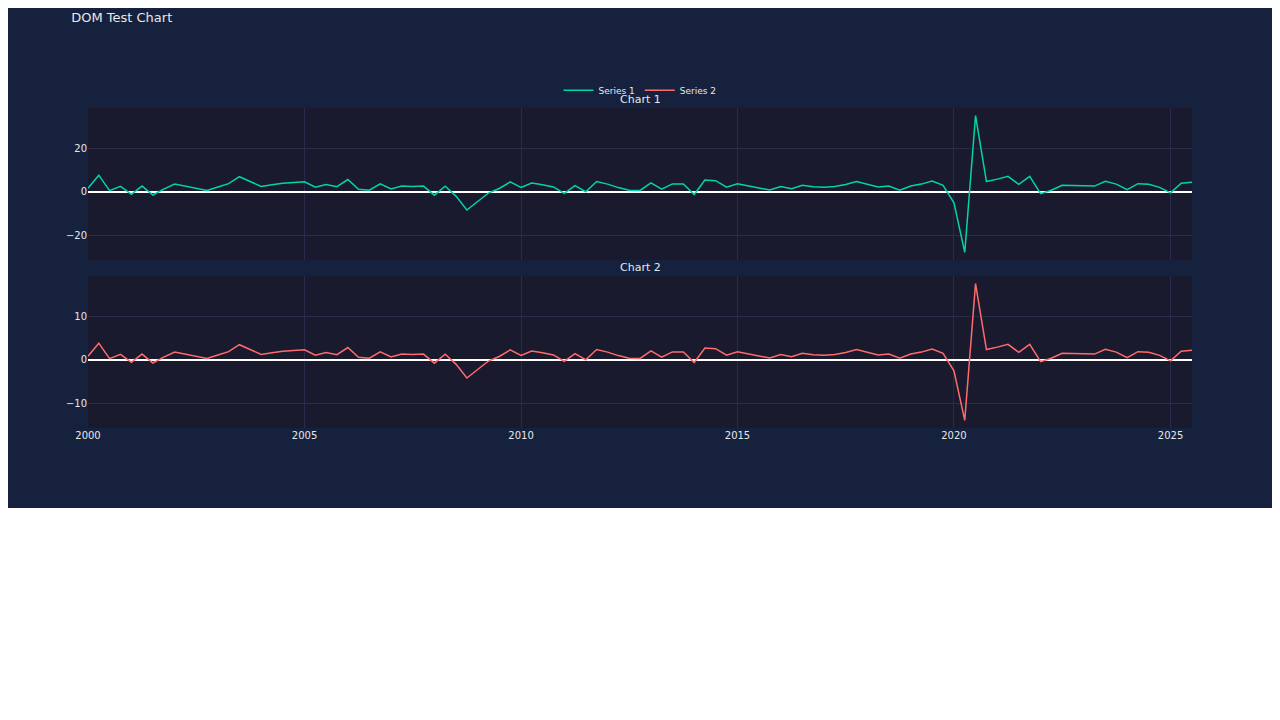

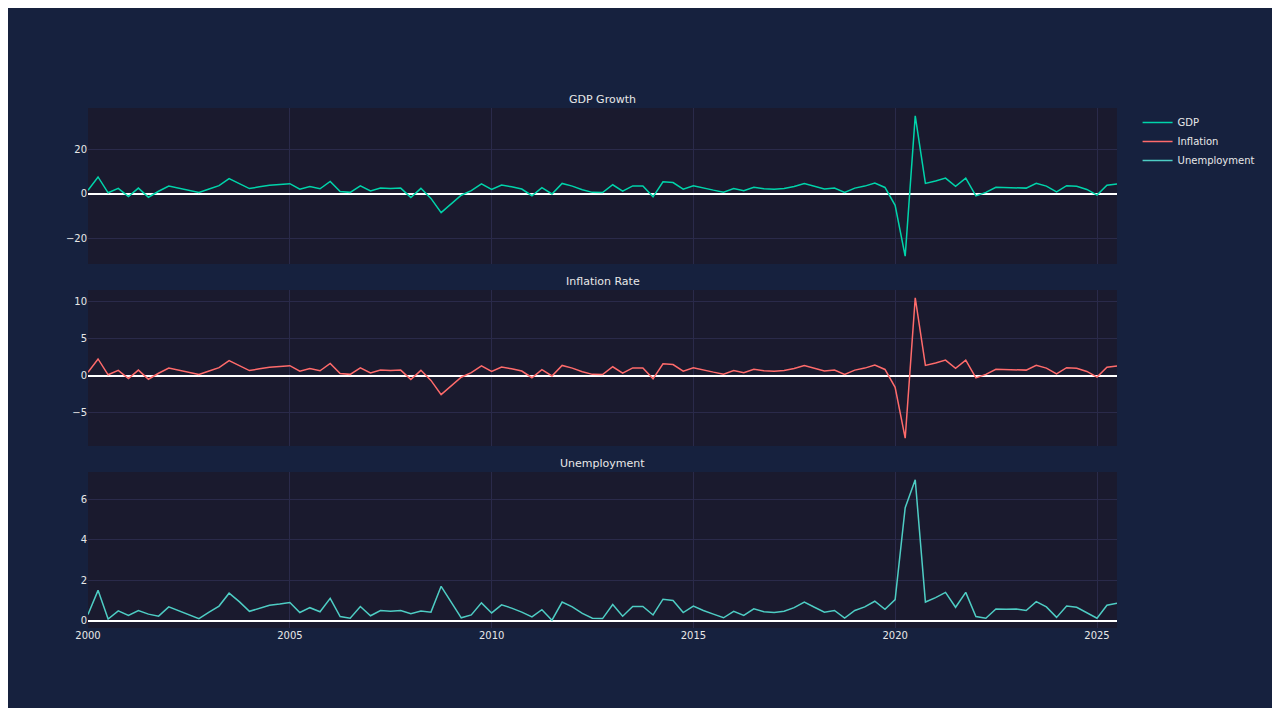

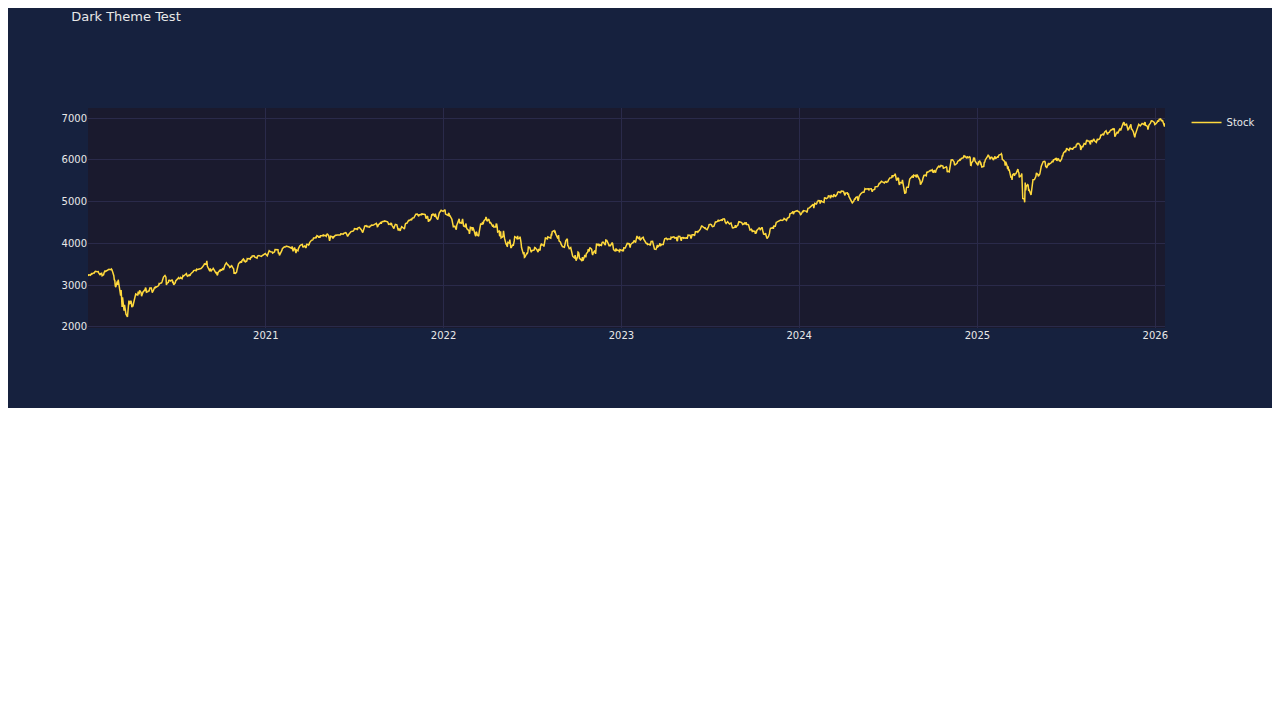

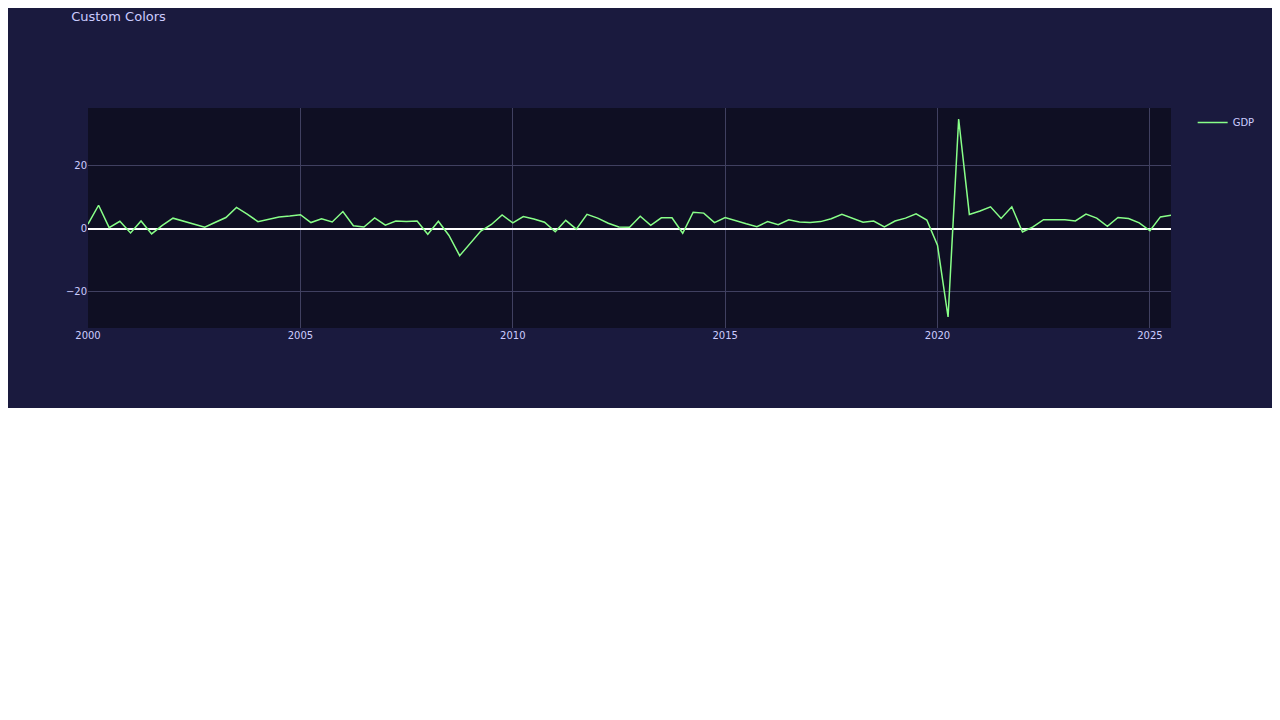

In [9]:
from pathlib import Path
from IPython.display import Image, display, HTML

screenshots_dir = Path('../test_output/screenshots')

if screenshots_dir.exists():
    screenshots = {
        'Single Subplot Chart': 'single_subplot.png',
        'Multi-Subplot Chart': 'multi_subplot.png',
        'Log Scale Chart': 'log_scale.png',
        'Scale Alignment Test': 'scale_alignment.png',
        'Multi-Series Scale Test': 'multi_series_scale.png',
        'Hover Tooltip Test': 'hover_tooltip.png',
        'Zoom Before': 'zoom_before.png',
        'Zoom After': 'zoom_after.png',
        'Zoom Reset (Zoomed)': 'zoom_reset_zoomed.png',
        'Zoom Reset (After Double-Click)': 'zoom_reset_after.png',
        'DOM Structure Test': 'dom_structure.png',
        'Subplot Titles Test': 'subplot_titles.png',
        'Dark Theme Test': 'dark_theme.png',
        'Custom Colors Test': 'custom_colors.png',
    }
    
    for title, filename in screenshots.items():
        path = screenshots_dir / filename
        if path.exists():
            display(HTML(f'<h3>{title}</h3>'))
            display(Image(filename=str(path), width=800))
        else:
            print(f"Screenshot not found: {filename}")
else:
    print("Screenshots directory not found. Run the tests first with: pytest tests/test_charts_visual.py")

## Interactive Features

All charts in this notebook support:

- **Hover**: Move your mouse over the chart to see data values
- **Zoom**: Click and drag to select an area to zoom in
- **Pan**: After zooming, drag to pan around
- **Reset**: Double-click to reset the view
- **Legend Toggle**: Click legend items to show/hide series